## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.

- 이미지가 격자로 작은 단위의 이미지 패치로 나뉘어 순차적으로 입력됨(BERT와의 차이)
- 셀프 어텐션 방법을 사용해 모든 이미지 패치가 서로에게 주는 영향을 고려해 이미지의 전체 특징을 추출.패치단위
(합성곱 신경망과의 차이)

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [1]:
!curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
!pip install torch~=2.1.0 torch_xla[tpu]~=2.1.0
!pip install timm

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     53      0 --:--:-- --:--:-- --:--:--    53
ERROR: Could not find a version that satisfies the requirement torch~=2.1.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch~=2.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 58.6 MB/s eta 0:00:00


### 데이터 불러오기

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/week9/train_images.zip -d /content/drive/MyDrive/week9

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/drive/MyDrive/week9/3952546193.jpg  
  inflating: /content/drive/MyDrive/week9/3952799769.jpg  
  inflating: /content/drive/MyDrive/week9/3953140534.jpg  
  inflating: /content/drive/MyDrive/week9/3953222407.jpg  
  inflating: /content/drive/MyDrive/week9/3953247024.jpg  
  inflating: /content/drive/MyDrive/week9/3953327881.jpg  
  inflating: /content/drive/MyDrive/week9/3953331047.jpg  
  inflating: /content/drive/MyDrive/week9/3953514366.jpg  
  inflating: /content/drive/MyDrive/week9/3953530273.jpg  
  inflating: /content/drive/MyDrive/week9/3953560426.jpg  
  inflating: /content/drive/MyDrive/week9/3953648207.jpg  
  inflating: /content/drive/MyDrive/week9/3953857113.jpg  
  inflating: /content/drive/MyDrive/week9/3953901317.jpg  
  inflating: /content/drive/MyDrive/week9/3954180556.jpg  
  inflating: /content/drive/MyDrive/week9/3954239221.jpg  
  inflating: /content/drive/MyDrive/week9/3954387963.jpg  
  inflating: /conten

In [4]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth.zip -d /content/drive/MyDrive/week9

unzip:  cannot find or open /content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth.zip, /content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth.zip.zip or /content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth.zip.ZIP.


In [5]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive"
TRAIN_PATH = "/content/drive/MyDrive/week9"
TEST_PATH = "/content/drive/MyDrive/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/jx_vit_base_p16_224-80ecf9dd.pth"
)

### 라이브러리

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import torch
import torch.nn as nn
import torchvision.transforms as transforms

import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.xla_multiprocessing as xmp
import torch_xla.distributed.parallel_loader as pl

import timm

import gc
import os
import time
import random
from datetime import datetime

from PIL import Image
from tqdm.notebook import tqdm
from sklearn import model_selection, metrics

In [7]:
os.environ["XLA_USE_BF16"] = "1"
os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [29]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [30]:
IMG_SIZE = 224  #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 16
LR = 2e-05
GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [31]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

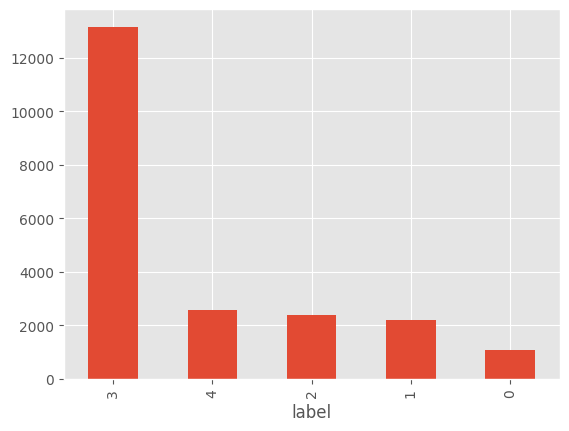

In [33]:
df.label.value_counts().plot(kind="bar")

In [35]:
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.9, random_state=0, stratify=df.label.values
)

In [34]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, data_path=DATA_PATH, mode="train", transforms=None):
        super().__init__()
        self.df_data = df.values
        self.data_path = data_path
        self.transforms = transforms
        self.mode = mode
        self.data_dir = "train_images" if mode == "train" else "test_images"

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.data_path, self.data_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [36]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [37]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [38]:
class ViTBase16(nn.Module):
    # ViTBase16 클래스 정의: PyTorch의 nn.Module을 상속받아 모델을 구성합니다.
    def __init__(self, n_classes, pretrained=False):
        # n_classes: 분류할 클래스의 개수 (예: 카사바 잎 질병 유형의 개수).
        # pretrained: 사전 학습된 모델을 사용할지 여부를 결정합니다.

        super(ViTBase16, self).__init__()

        self.model = timm.create_model("vit_base_patch16_224", pretrained=False)
        # timm 라이브러리를 사용하여 "vit_base_patch16_224" 모델을 생성합니다.
        # 기본적으로 pretrained=False로 설정하여 timm 자체의 사전 학습 가중치는 로드하지 않습니다.
        if pretrained:
            # pretrained가 True인 경우, 사용자가 제공한 특정 경로에서 사전 학습된 가중치를 로드합니다.
            self.model.load_state_dict(torch.load(MODEL_PATH))

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)
        # Vision Transformer의 마지막 분류 헤드(head)를 수정합니다.
        # 원래 모델의 출력 특성 수(self.model.head.in_features)를 유지하면서,
        # 분류할 클래스 수(n_classes)에 맞게 출력 레이어(nn.Linear)를 새로 만듭니다.
        # 이는 전이 학습(Transfer Learning)을 위한 일반적인 단계

    def forward(self, x):
        x = self.model(x)
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        # criterion CrossEntropyLoss.
        # optimizer:Adam.

        epoch_loss = 0.0
        epoch_accuracy = 0.0

        self.model.train()
        for i, (data, target) in enumerate(train_loader):
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                # 장치가 XLA(TPU)인 경우, 데이터와 타겟을 TPU로 이동시키고 데이터 타입을 지정합니다.
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            optimizer.zero_grad()
            output = self.forward(data)
            loss = criterion(output, target)
            loss.backward()
            accuracy = (output.argmax(dim=1) == target).float().mean()

            epoch_loss += loss
            epoch_accuracy += accuracy

            if device.type == "xla":
                # 장치가 XLA(TPU)인 경우, xm.optimizer_step을 사용하여 옵티마이저 스텝을 수행합니다.
                xm.optimizer_step(optimizer)

                if i % 20 == 0:
                    xm.master_print(f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss}")

            else:
                optimizer.step()

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)
        # 한 에포크 동안의 평균 손실과 평균 정확도를 반환합니다.

    def validate_one_epoch(self, valid_loader, criterion, device):
        valid_loss = 0.0
        valid_accuracy = 0.0

        self.model.eval()
        for data, target in valid_loader:
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            with torch.no_grad():
                # 그래디언트 계산을 비활성화하여 메모리 사용량을 줄이고 계산 속도를 높입니다.
                output = self.model(data)
                loss = criterion(output, target)
                accuracy = (output.argmax(dim=1) == target).float().mean()

                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [39]:
def fit_tpu(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        para_train_loader = pl.ParallelLoader(train_loader, [device])

        xm.master_print(f"{'='*50}")
        xm.master_print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            para_train_loader.per_device_loader(device), criterion, optimizer, device
        )
        xm.master_print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            gc.collect()
            para_valid_loader = pl.ParallelLoader(valid_loader, [device])
            xm.master_print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(
                para_valid_loader.per_device_loader(device), criterion, device
            )
            xm.master_print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)
            gc.collect()

            if valid_loss <= valid_loss_min and epoch != 1:
                xm.master_print(
                    "Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [40]:
model = ViTBase16(n_classes=5, pretrained=True)

In [45]:
def _run():
    train_dataset = CassavaDataset(train_df, transforms=transforms_train)
    valid_dataset = CassavaDataset(valid_df, transforms=transforms_valid)

    train_sampler = torch.utils.data.distributed.DistributedSampler(
        train_dataset,
        num_replicas=torch_xla.runtime.world_size(),
        rank=torch_xla.runtime.global_ordinal() ,
        shuffle=True,
    )

    valid_sampler = torch.utils.data.distributed.DistributedSampler(
        valid_dataset,
        num_replicas=torch_xla.runtime.world_size(),
        rank=torch_xla.runtime.global_ordinal() ,
        shuffle=False,
    )

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        drop_last=True,
        num_workers=8,
    )

    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset,
        batch_size=BATCH_SIZE,
        sampler=valid_sampler,
        drop_last=True,
        num_workers=8,
    )

    criterion = nn.CrossEntropyLoss()  #cross entropy loss로 설정.
    device = xm.xla_device()
    model.to(device)

    lr = LR * torch_xla.runtime.world_size()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    xm.master_print(f"INITIALIZING TRAINING ON {torch_xla.runtime.world_size()} TPU CORES")
    start_time = datetime.now()
    xm.master_print(f"Start Time: {start_time}")

    logs = fit_tpu(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    xm.master_print(f"Execution time: {datetime.now() - start_time}")

    xm.master_print("Saving Model")
    xm.save(
        model.state_dict(), f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )

In [46]:
# Training 시작
def _mp_fn(rank, flags):
    torch.set_default_tensor_type("torch.FloatTensor")
    a = _run()


# Run
FLAGS = {}
xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=1, start_method="fork")

/tmp/ipykernel_374/4116039966.py:36: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


INITIALIZING TRAINING ON 1 TPU CORES
Start Time: 2026-05-11 14:43:23.186515
EPOCH 1 - TRAINING...


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
Exception in thread Thread-4 (_loader_worker):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch_xla/distributed/parallel_loader.py", line 165, in _loader_worker
    _, data = next(data_iter)
              ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 732, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^


	[TRAIN] EPOCH 1 - LOSS: 0.0, ACCURACY: 0.0

EPOCH 1 - VALIDATING...


Exception in thread Thread-6 (_loader_worker):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch_xla/distributed/parallel_loader.py", line 165, in _loader_worker
    _, data = next(data_iter)
              ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 732, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1506, in _next_data
    return self._process_data(data, worker_id)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1541, in _process_data
    data.reraise()
  File "/usr/local/lib/python3.12/dist-packages/torch/

	[VALID] LOSS: 0.0, ACCURACY: 0.0

Execution time: 0:00:54.261806
Saving Model
